In [2]:
import cv2
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os

In [8]:
pip install ultralytics opencv-python numpy torch torchvision torchaudio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 20.9 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [79]:
def remover_background(image_link):
    imaj = cv2.imread(image_link)
    imaj = cv2.cvtColor(imaj, cv2.COLOR_BGR2RGB)
    
    #creating the mask as the image is 
    #in grabcut this mask will be used for background (0) foreground(1)
    mask = np.zeros(imaj.shape[:2], np.uint8) 


    
    #stores the probability distribution of background and foreground
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    #rectangular we will focus (ROI)
    rect = (30, 30, imaj.shape[1] - 50, imaj.shape[0] - 50)  # Define a rough bounding box


    #image: Input image.
    #mask: Initial mask (which is all zeros initially).
    #rect: Defines the rough foreground area.
    #bg_model: Stores the background GMM parameters.
    #fg_model: Stores the foreground GMM parameters.
    #5: Number of iterations GrabCut runs.
    #cv2.GC_INIT_WITH_RECT: Indicates that we're initializing with a rectangle (not a pre-defined mask).
    cv2.grabCut(imaj, mask, rect, bg_model, fg_model, 10, cv2.GC_INIT_WITH_RECT) 
    
    #0 (cv2.GC_BGD) → Sure Background (Set to 0)
    #1 (cv2.GC_FGD) → Sure Foreground (Set to 1)
    #2 (cv2.GC_PR_BGD) → Probable Background (Set to 0)
    #3 (cv2.GC_PR_FGD) → Probable Foreground (Set to 1)
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    

    #image*mask2 -- gives directly foreground
    foreground = imaj * mask2[:, :, np.newaxis]

    
    foreground = cv2.resize(foreground,(224,224))

    return foreground

In [22]:
new_img = '/kaggle/input/bebekamin/dneeme.PNG'

org_imaj = cv2.imread(new_img)
org_imaj = cv2.cvtColor(org_imaj, cv2.COLOR_BGR2RGB)

grab_imj = remover_background(new_img)

In [30]:
grab_imj_inc_iter = remover_background(new_img)

In [34]:
grab_imj_inc_iter_more = remover_background(new_img)

In [23]:
from ultralytics import YOLO

# Load the YOLOv8 model
model = YOLO("yolov8n.pt",verbose = False)  # Load pre-trained weights

results = model(new_img)
for result in results:
    for box in result.boxes:
        class_id = int(box.cls) #  Get class ID
        class_name = model.names[class_id]
        x1,y1,x2,y2 = box.xyxy[0].tolist()
        top_left = (int(x1),int(y1))
        buttom_right = (int(x2),int(y2))

        yolo_imaj = cv2.rectangle(org_imaj.copy(),top_left,buttom_right,(0,255,0),2)


image 1/1 /kaggle/input/bebekamin/dneeme.PNG: 640x640 1 person, 167.4ms
Speed: 3.6ms preprocess, 167.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


Text(0.5, 1.0, 'person')

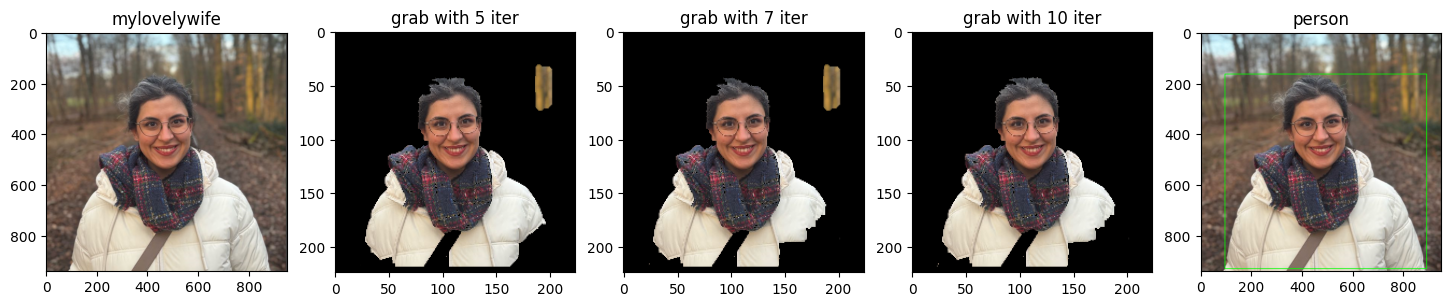

In [37]:
fig, ax = plt.subplots(1,5,figsize=(18,8))

ax[0].imshow(org_imaj)
ax[0].set_title('mylovelywife')

ax[1].imshow(grab_imj)
ax[1].set_title('grab with 5 iter')

ax[2].imshow(grab_imj_inc_iter)
ax[2].set_title('grab with 7 iter')

ax[3].imshow(grab_imj_inc_iter_more)
ax[3].set_title('grab with 10 iter')

ax[4].imshow(yolo_imaj)
ax[4].set_title(str(class_name))

# Test with different data

In [38]:
file_img = '/kaggle/input/platesv2/plates.zip'
file_out = '/kaggle/working'

import zipfile
# Open the ZIP file
with zipfile.ZipFile(file_img, 'r') as zip_ref:
    # Extract all contents to a directory
    zip_ref.extractall(file_out)
print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [44]:
test_link = '/kaggle/working/plates/test'
test = []
for dirname,_,filenames in os.walk(test_link):
    for f in filenames:
        test.append(os.path.join(test_link,f))
print(test[:5])
print(len(test))

['/kaggle/working/plates/test/0567.jpg', '/kaggle/working/plates/test/0397.jpg', '/kaggle/working/plates/test/0442.jpg', '/kaggle/working/plates/test/0525.jpg', '/kaggle/working/plates/test/0358.jpg']
745


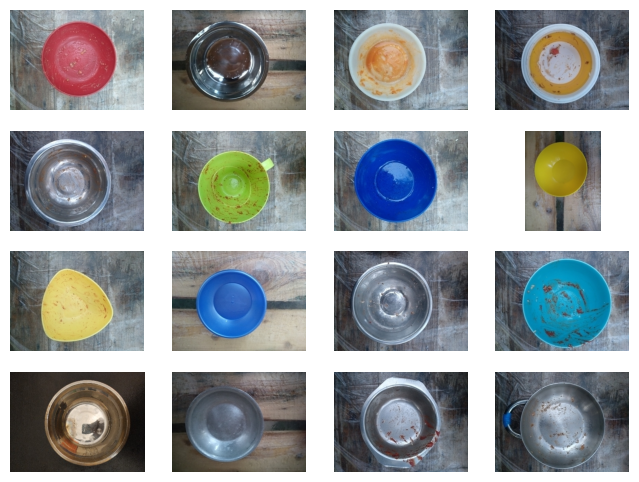

In [76]:
import random 

samples = []
for i in range(16):
    samples.append(random.choice(test))

fig, ax = plt.subplots(4,4,figsize=(8,6))
for i in range(4):
    for j in range(4):
        imaj = cv2.imread(samples[i*4+j])
        imaj = cv2.cvtColor(imaj, cv2.COLOR_BGR2RGB)
        ax[i][j].imshow(imaj)
        ax[i][j].axis('off')

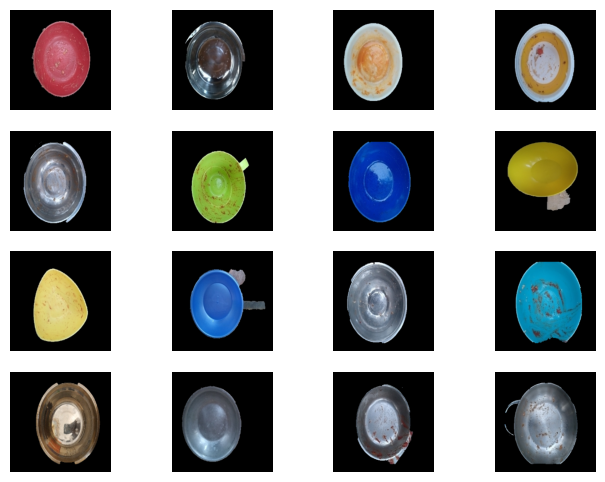

In [77]:
# ITERATION CUT 5

fig, ax = plt.subplots(4,4,figsize=(8,6))

for i in range(4):
    for j in range(4):
        imaj = remover_background(samples[i*4+j])
        ax[i][j].imshow(imaj)
        ax[i][j].axis('off')

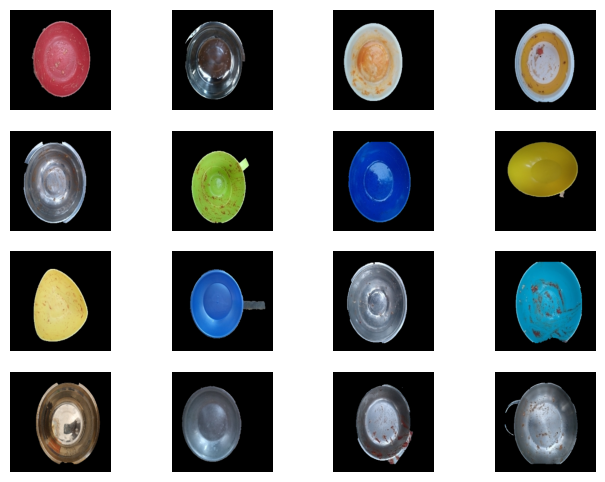

In [80]:
# ITERATION CUT 10

fig, ax = plt.subplots(4,4,figsize=(8,6))

for i in range(4):
    for j in range(4):
        imaj = remover_background(samples[i*4+j])
        ax[i][j].imshow(imaj)
        ax[i][j].axis('off')

**10 gives better result. look at the images above**